# Week 1 — Day 3: Resampling & Time-Series Decomposition

**Dataset:** `data/supply_chain_cleaned_data.csv` (the finalized dataset)  
**Goal today:**
1. Prep the finalized data into a **continuous daily series per category**
   (average duplicate (date, category) keys; keep all 11 categories separate).
2. **Resample** the daily demand to weekly and monthly aggregates.
3. **Decompose** each category's demand into **trend / seasonal / residual**
   with `statsmodels.seasonal_decompose`.

> Note: `Clothing` has only ~192 observations, so its continuous series is mostly
> interpolated (largely synthetic) — interpret its decomposition with caution.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DATA_PATH = Path('..') / 'data' / 'supply_chain_cleaned_data.csv'
OUT_PATH = Path('..') / 'data' / 'processed' / 'supply_chain_daily.csv'

NUM_COLS = ['units_sold', 'inventory_level', 'unit_price', 'warehouse_dispatch_rate']
TARGET = 'units_sold'  # the demand series we decompose

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print('Loaded shape:', df.shape)
print('Date range:', df['date'].min().date(), '->', df['date'].max().date())
df.head()

Loaded shape: (11000, 7)
Date range: 2020-01-01 -> 2023-04-01


,date,product_category,units_sold,inventory_level,unit_price,promotion_flag,warehouse_dispatch_rate
0,2020-01-01,Electronics,177.1,528.9,46.33,False,178.1
1,2020-01-01,Pet Supplies,298.5,804.4,196.85,False,306.6
2,2020-01-01,Beauty,292.3,1029.7,165.15,False,305.7
3,2020-01-01,Sporting Goods,453.3,1397.7,126.80,False,472.3
4,2020-01-01,Furniture,261.3,780.4,73.82,False,243.5


## 1. Collapse duplicate (date, category) keys

Some (date, category) pairs appear more than once. We average the numeric columns
so each category has at most one row per day. `promotion_flag` becomes `True` if any
of the duplicated rows was on promotion.

In [11]:
dup_keys = int(df.duplicated(['date', 'product_category']).sum())
print('Duplicate (date, category) rows to average:', dup_keys)

agg = (df.groupby(['date', 'product_category'], as_index=False)
         .agg(units_sold=('units_sold', 'mean'),
              inventory_level=('inventory_level', 'mean'),
              unit_price=('unit_price', 'mean'),
              warehouse_dispatch_rate=('warehouse_dispatch_rate', 'mean'),
              promotion_flag=('promotion_flag', 'max')))
print('Rows after averaging duplicates:', len(agg))
print('Unique (date, category) now    :', int(agg.duplicated(['date', 'product_category']).sum()) == 0)
agg.head()

Duplicate (date, category) rows to average: 629
Rows after averaging duplicates: 10371
Unique (date, category) now    : True


,date,product_category,units_sold,inventory_level,unit_price,warehouse_dispatch_rate,promotion_flag
0,2020-01-01,Apparel,453.9,719.0,168.09,426.4,False
1,2020-01-01,Automotive Parts,339.5,656.2,223.74,311.8,False
2,2020-01-01,Beauty,292.3,1029.7,165.15,305.7,False
3,2020-01-01,Electronics,177.1,528.9,46.33,178.1,False
4,2020-01-01,Furniture,261.3,780.4,73.82,243.5,False


## 2. Build a continuous daily series per category

Reindex every category onto the full daily calendar (2020-01-01 → 2023-04-01) and
linearly interpolate the numeric gaps so each category is gap-free — a requirement
for decomposition and forecasting. Days created by reindexing are marked
`promotion_flag = False`.

In [12]:
categories = sorted(agg['product_category'].unique())
full_range = pd.date_range(agg['date'].min(), agg['date'].max(), freq='D')
print('Categories:', categories)
print('Daily calendar length:', len(full_range), 'days')

# report coverage so sparse categories (e.g. Clothing) are visible
coverage = (agg.groupby('product_category')['date'].nunique()
               .reindex(categories)
               .to_frame('observed_days'))
coverage['calendar_days'] = len(full_range)
coverage['coverage_%'] = (100 * coverage['observed_days'] / len(full_range)).round(1)
print(coverage)

frames = []
for cat in categories:
    sub = (agg[agg['product_category'] == cat]
           .set_index('date')
           .sort_index()
           .reindex(full_range))
    sub.index.name = 'date'
    sub['product_category'] = cat
    sub[NUM_COLS] = sub[NUM_COLS].interpolate(method='linear', limit_direction='both')
    sub['promotion_flag'] = sub['promotion_flag'] == True  # NaN (reindexed days) -> False
    frames.append(sub.reset_index())

daily = pd.concat(frames, ignore_index=True)
daily[NUM_COLS] = daily[NUM_COLS].round(2)
daily = daily[['date', 'product_category', *NUM_COLS, 'promotion_flag']]
daily = daily.sort_values(['product_category', 'date']).reset_index(drop=True)

# validate
assert daily[NUM_COLS].isna().sum().sum() == 0, 'Missing values remain!'
assert daily.duplicated(['date', 'product_category']).sum() == 0, 'Duplicate keys!'
assert len(daily) == len(full_range) * len(categories), 'Series is not continuous!'
print('Continuous daily series OK:', daily.shape)
daily.head()

Categories: ['Apparel', 'Automotive Parts', 'Beauty', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Office Supplies', 'Pet Supplies', 'Sporting Goods', 'Toys']
Daily calendar length: 1187 days
                  observed_days  calendar_days  coverage_%
product_category                                          
Apparel                     872           1187        73.5
Automotive Parts           1036           1187        87.3
Beauty                     1046           1187        88.1
Clothing                    190           1187        16.0
Electronics                1034           1187        87.1
Furniture                  1027           1187        86.5
Groceries                  1033           1187        87.0
Office Supplies            1035           1187        87.2
Pet Supplies               1041           1187        87.7
Sporting Goods             1025           1187        86.4
Toys                       1032           1187        86.9


Continuous daily series OK: (13057, 7)


,date,product_category,units_sold,inventory_level,unit_price,warehouse_dispatch_rate,promotion_flag
0,2020-01-01,Apparel,453.9,719.0,168.09,426.4,False
1,2020-01-02,Apparel,445.1,716.9,171.46,69.9,False
2,2020-01-03,Apparel,483.4,711.2,167.15,463.2,False
3,2020-01-04,Apparel,600.6,712.1,172.11,557.1,True
4,2020-01-05,Apparel,407.2,1216.3,171.24,422.8,False


## 3. Save the processed daily series

In [13]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
daily.to_csv(OUT_PATH, index=False)
print('Saved ->', OUT_PATH.resolve())
print('Rows:', len(daily), '| Columns:', list(daily.columns))

Saved -> C:\Users\hemangi\Desktop\Supply Chain Analytics - Demand Forecasting\data\processed\supply_chain_daily.csv
Rows: 13057 | Columns: ['date', 'product_category', 'units_sold', 'inventory_level', 'unit_price', 'warehouse_dispatch_rate', 'promotion_flag']


## 4. Resample demand to weekly and monthly

Aggregate daily `units_sold` to weekly (`W`) and monthly (`MS`) totals per category —
smoother views that make trend and seasonality easier to see.

In [14]:
def resample_demand(frame, rule):
    """Sum units_sold to the given frequency for each category."""
    out = (frame.set_index('date')
                .groupby('product_category')[TARGET]
                .resample(rule).sum()
                .rename(TARGET)
                .reset_index())
    return out

weekly = resample_demand(daily, 'W')
monthly = resample_demand(daily, 'MS')
print('Weekly rows :', len(weekly))
print('Monthly rows:', len(monthly))
monthly.head()

Weekly rows : 1870
Monthly rows: 440


,product_category,date,units_sold
0,Apparel,2020-01-01,14077.15
1,Apparel,2020-02-01,12568.12
2,Apparel,2020-03-01,12986.33
3,Apparel,2020-04-01,12240.40
4,Apparel,2020-05-01,12914.25


## 5. Visualize daily vs weekly vs monthly (one category)

A quick look at how resampling smooths the series.

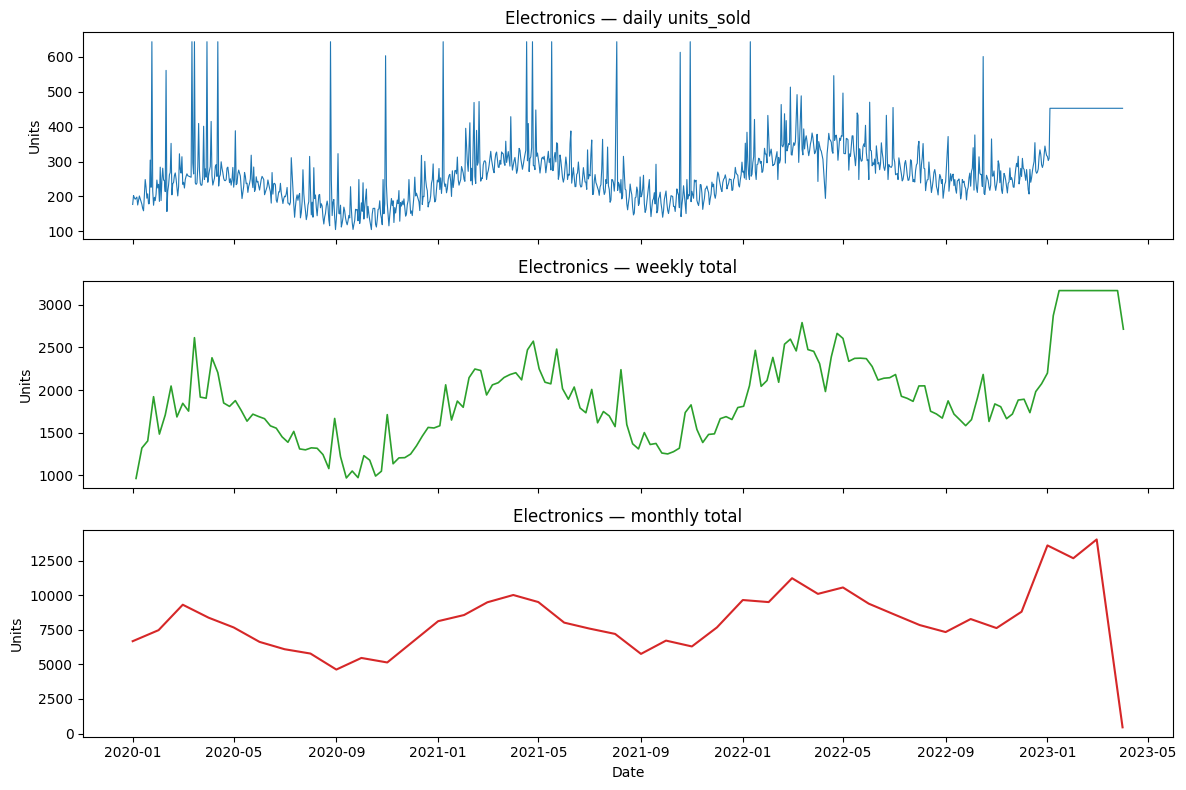

In [15]:
cat = 'Electronics'
d = daily[daily['product_category'] == cat].set_index('date')[TARGET]
w = weekly[weekly['product_category'] == cat].set_index('date')[TARGET]
m = monthly[monthly['product_category'] == cat].set_index('date')[TARGET]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(d.index, d.values, color='tab:blue', lw=0.8);   axes[0].set_title(f'{cat} — daily units_sold')
axes[1].plot(w.index, w.values, color='tab:green', lw=1.2);  axes[1].set_title(f'{cat} — weekly total')
axes[2].plot(m.index, m.values, color='tab:red', lw=1.5);    axes[2].set_title(f'{cat} — monthly total')
for ax in axes:
    ax.set_ylabel('Units')
axes[-1].set_xlabel('Date')
plt.tight_layout(); plt.show()

## 6. Seasonal decomposition (trend / seasonal / residual)

We decompose the **daily** demand with a weekly period (`period=7`) to expose the
within-week pattern, using an additive model. `seasonal_decompose` splits the
series into `trend + seasonal + residual`.

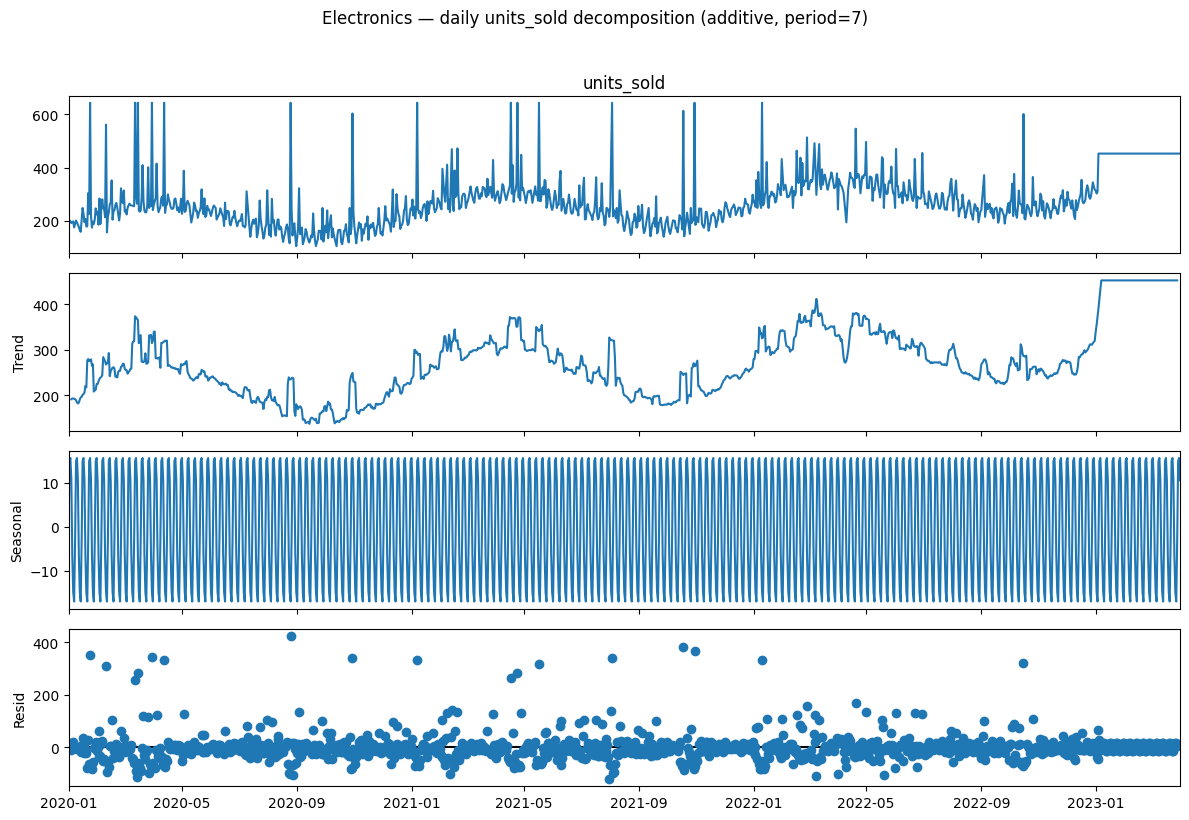

In [16]:
cat = 'Electronics'
series = daily[daily['product_category'] == cat].set_index('date')[TARGET].asfreq('D')

result = seasonal_decompose(series, model='additive', period=7)
fig = result.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f'{cat} — daily units_sold decomposition (additive, period=7)', y=1.02)
plt.tight_layout(); plt.show()

## 7. Monthly decomposition — annual seasonality

On the monthly series a period of 12 exposes the **yearly** seasonal shape, which is
more useful for demand planning than the weekly pattern.

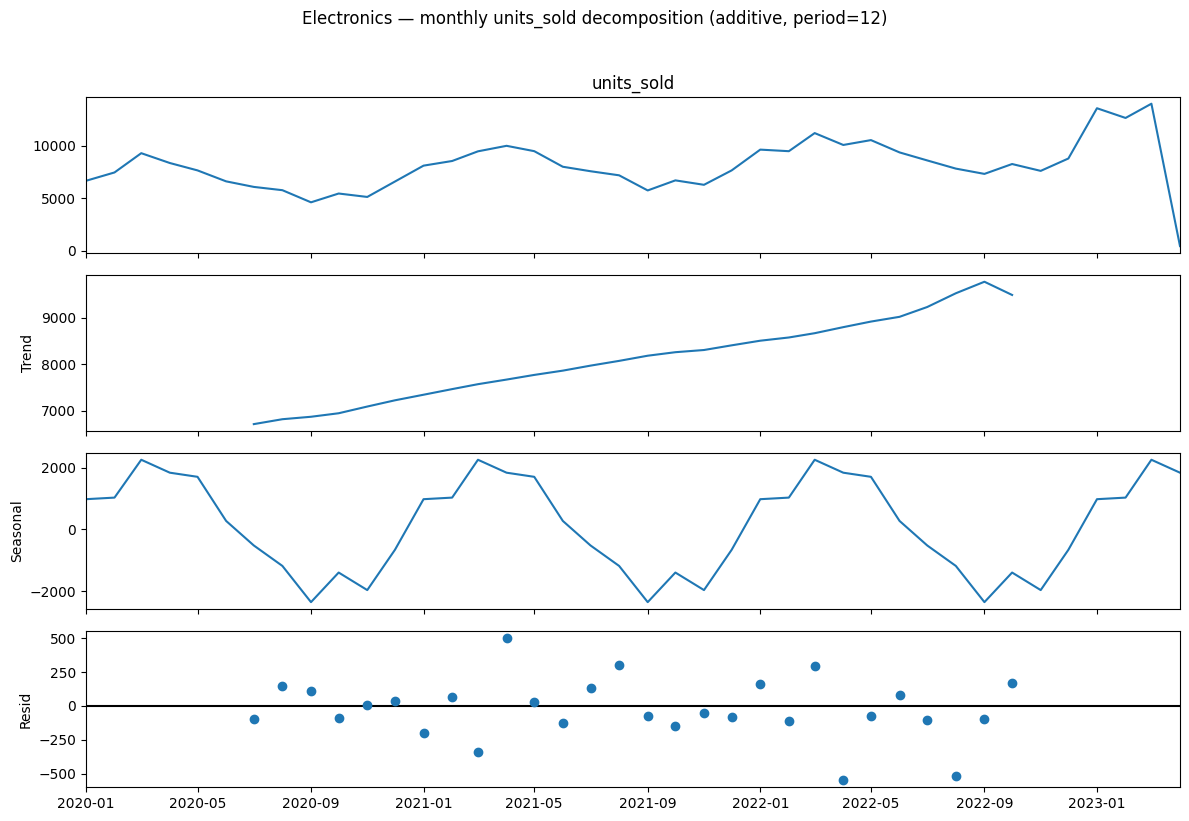

In [17]:
m_series = (monthly[monthly['product_category'] == cat]
            .set_index('date')[TARGET]
            .asfreq('MS'))

m_result = seasonal_decompose(m_series, model='additive', period=12)
fig = m_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f'{cat} — monthly units_sold decomposition (additive, period=12)', y=1.02)
plt.tight_layout(); plt.show()

## 8. Seasonal strength across all categories

A compact summary: for each category, how strong is the yearly seasonality relative
to the residual noise? We use  `max(0, 1 - Var(resid) / Var(seasonal + resid))`
on the monthly series as a simple seasonal-strength score in [0, 1].

In [18]:
rows = []
for c in categories:
    s = monthly[monthly['product_category'] == c].set_index('date')[TARGET].asfreq('MS')
    res = seasonal_decompose(s, model='additive', period=12)
    resid = res.resid.dropna()
    seas = res.seasonal.reindex(resid.index)
    denom = np.var(seas + resid)
    strength = max(0.0, 1 - np.var(resid) / denom) if denom > 0 else np.nan
    rows.append({'category': c,
                 'mean_monthly_units': round(s.mean(), 1),
                 'trend_change': round(res.trend.dropna().iloc[-1] - res.trend.dropna().iloc[0], 1),
                 'seasonal_strength': round(strength, 3)})

summary = pd.DataFrame(rows).sort_values('seasonal_strength', ascending=False).reset_index(drop=True)
summary

,category,mean_monthly_units,trend_change,seasonal_strength
0,Furniture,9131.4,829.0,0.981
1,Electronics,8108.0,2785.6,0.978
2,Sporting Goods,15921.3,1238.5,0.976
3,Office Supplies,11508.4,2250.4,0.971
4,Apparel,13877.4,1231.1,0.967
5,Beauty,11922.1,1168.9,0.940
6,Toys,9468.0,1147.3,0.936
7,Automotive Parts,10079.4,1061.8,0.933
8,Groceries,9537.6,2818.1,0.854
9,Pet Supplies,10363.6,3220.6,0.851
